<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bar Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be provided to you in the form of an RDBMS.

You will use SQL queries to extract the necessary data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data

-   Visualize the relationship between two features

-   Visualize the composition of data

-   Visualize comparison of data


## Setup: Working with the Database
**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 141.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 165.7 MB/s eta 0:00:00


In [6]:
!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [7]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Step 2: Import necessary libraries and load the dataset
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows to understand the structure of the data
df.head()


--2026-04-01 13:57:57--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  37.4MB/s    in 4.3s    

2026-04-01 13:58:02 (35.3 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Visualizing Data Distributions


##### 1. Histogram of `ConvertedCompYearly`


Visualize the distribution of yearly compensation (`ConvertedCompYearly`) using a histogram.



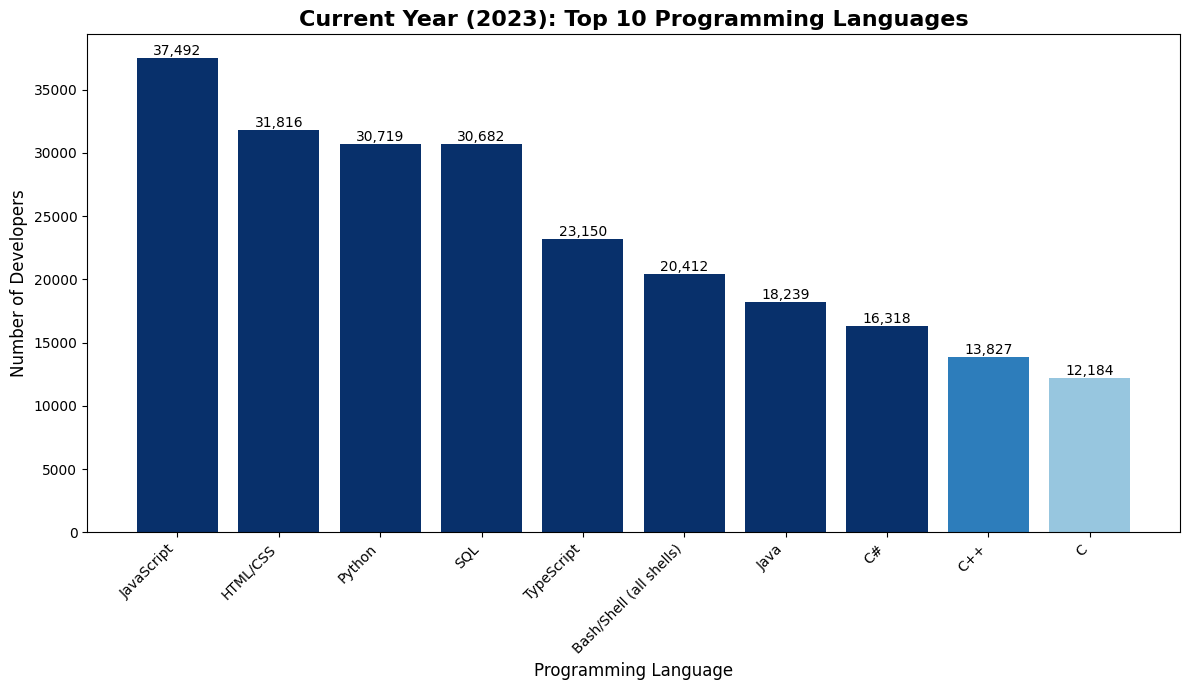

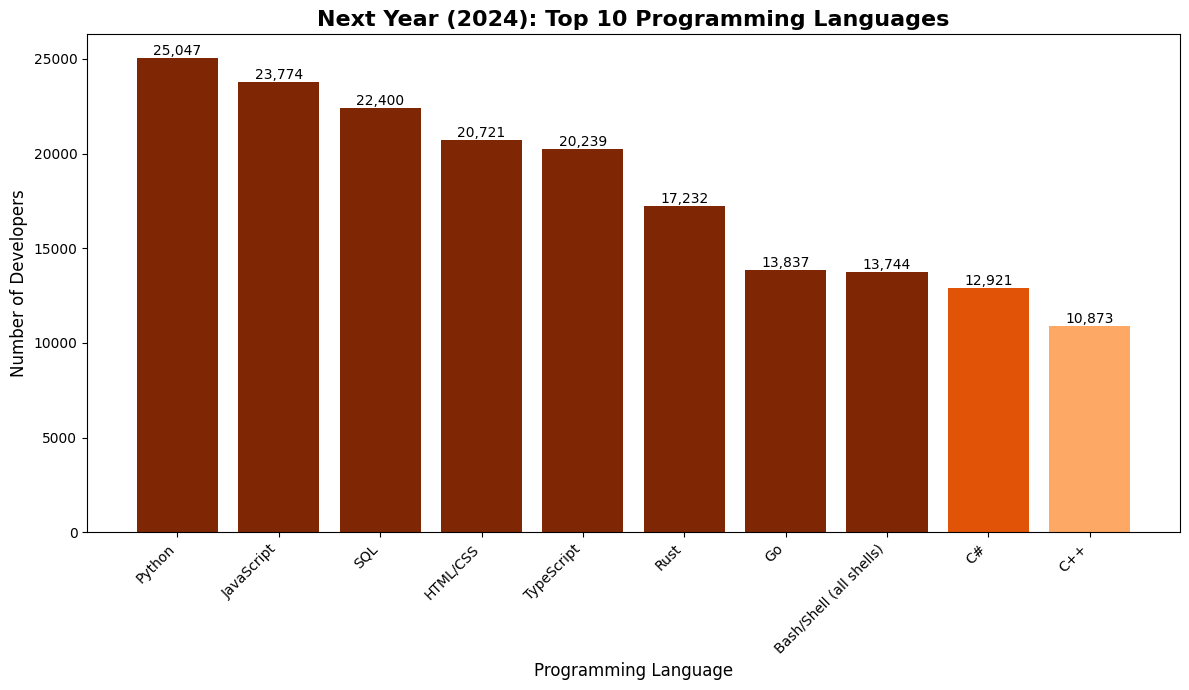

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data

# Current Year: Top 10 Programming Languages
current_langs = df['LanguageHaveWorkedWith'].str.split(';').explode().value_counts().nlargest(10)

# Create bar chart
plt.figure(figsize=(12, 7))
colors = plt.cm.Blues(range(100, 900, 80))[::-1]  # Gradient blues
bars = plt.bar(current_langs.index, current_langs.values, color=colors)
plt.title('Current Year (2023): Top 10 Programming Languages', fontsize=16, fontweight='bold')
plt.xlabel('Programming Language', fontsize=12)
plt.ylabel('Number of Developers', fontsize=12)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Next Year (2024)
future_langs = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts().nlargest(10)

plt.figure(figsize=(12, 7))
colors = plt.cm.Oranges(range(100, 900, 80))[::-1]
bars = plt.bar(future_langs.index, future_langs.values, color=colors)
plt.title('Next Year (2024): Top 10 Programming Languages', fontsize=16, fontweight='bold')
plt.xlabel('Programming Language', fontsize=12)
plt.ylabel('Number of Developers', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### 2. Box Plot of `Age`


Since `Age` is categorical in the dataset, convert it to numerical values for a box plot.



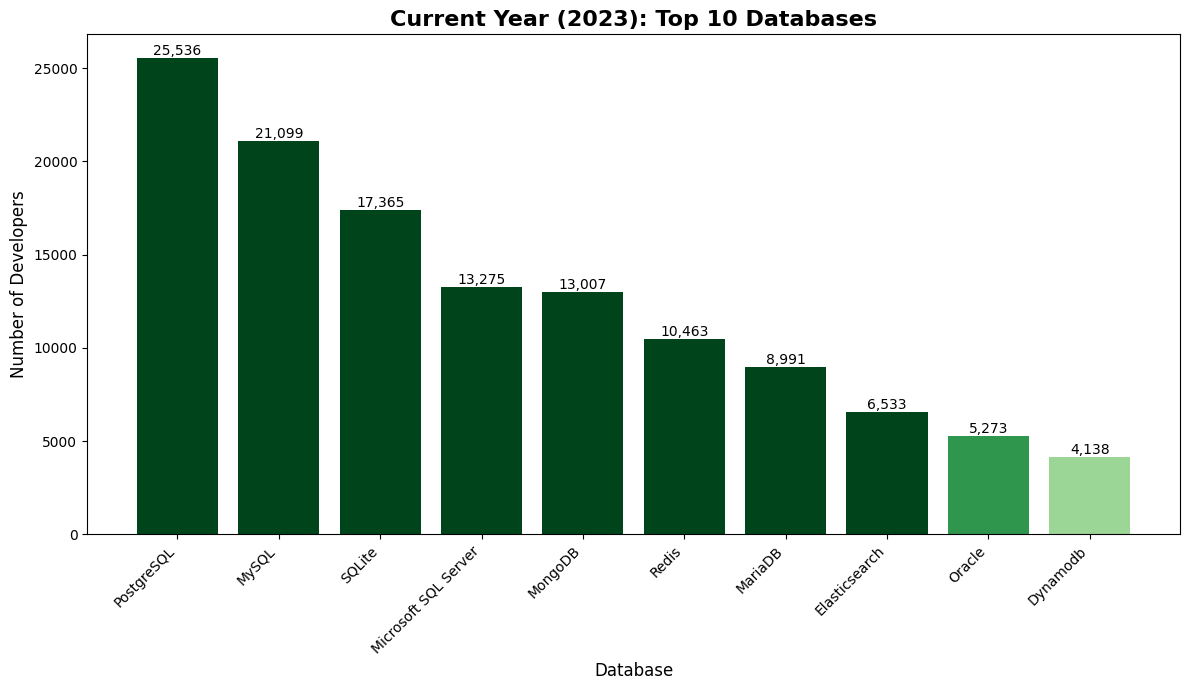

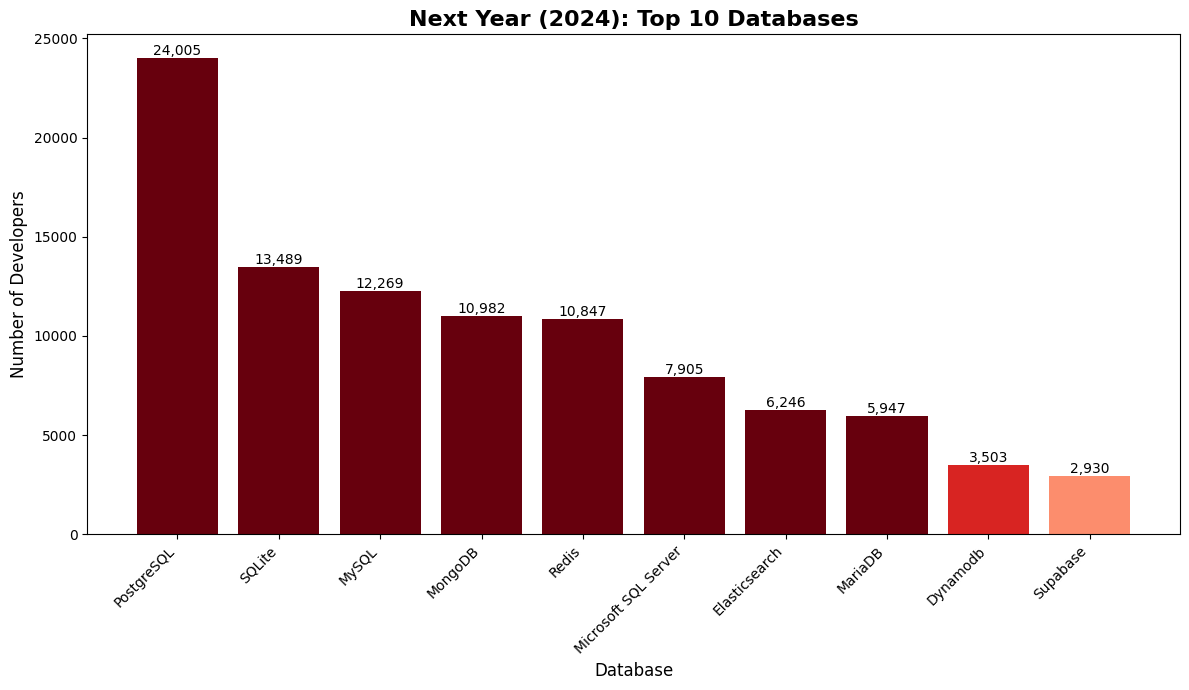

In [18]:
# Current Year: Top 10 Databases
current_dbs = df['DatabaseHaveWorkedWith'].str.split(';').explode().value_counts().nlargest(10)

plt.figure(figsize=(12, 7))
colors = plt.cm.Greens(range(100, 900, 80))[::-1]
bars = plt.bar(current_dbs.index, current_dbs.values, color=colors)
plt.title('Current Year (2023): Top 10 Databases', fontsize=16, fontweight='bold')
plt.xlabel('Database', fontsize=12)
plt.ylabel('Number of Developers', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Next Year: Top 10 Databases
future_dbs = df['DatabaseWantToWorkWith'].str.split(';').explode().value_counts().nlargest(10)

plt.figure(figsize=(12, 7))
colors = plt.cm.Reds(range(100, 900, 80))[::-1]
bars = plt.bar(future_dbs.index, future_dbs.values, color=colors)
plt.title('Next Year (2024): Top 10 Databases', fontsize=16, fontweight='bold')
plt.xlabel('Database', fontsize=12)
plt.ylabel('Number of Developers', fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Task 2: Visualizing Relationships in Data


##### 1. Scatter Plot of `Age_numeric` and `ConvertedCompYearly`


Explore the relationship between age and compensation.



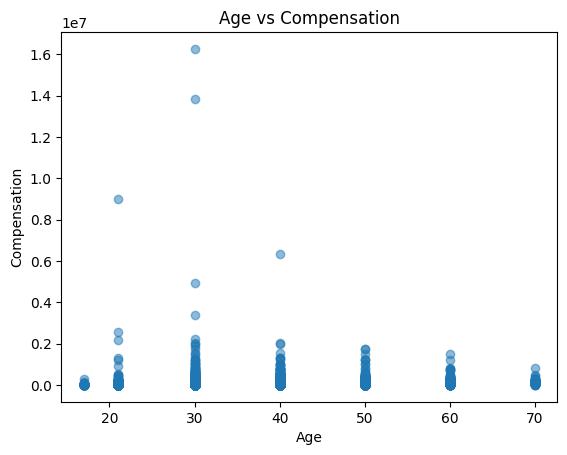

In [14]:
# ============================================
# PAGE 18: APPENDIX - Additional Charts
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests

# First, load your main survey data
print("Loading survey data...")
try:
    df = pd.read_csv('survey_data_compressed (1).csv')
    print(f"✓ Loaded {len(df)} records from survey data")
except FileNotFoundError:
    print("Survey data file not found. Please ensure 'survey_data_compressed (1).csv' is in the directory.")
    # Create sample data for demonstration if needed
    # In practice, you should have the actual file

# ============================================
# ADDITIONAL CHART 1: Job Satisfaction Distribution
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 1: Job Satisfaction Distribution")
print("="*60)

# Clean job satisfaction data
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
job_sat_clean = df['JobSatPoints_6'].dropna()

# Create histogram
plt.figure(figsize=(12, 6))
plt.hist(job_sat_clean, bins=10, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Distribution of Job Satisfaction Scores\n(1 = Very Dissatisfied, 10 = Very Satisfied)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction Score', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('appendix_job_satisfaction.png', dpi=300, bbox_inches='tight')


# ============================================
# ADDITIONAL CHART 2: Age Distribution of Developers
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 2: Age Distribution of Developers")
print("="*60)

# Age mapping
age_mapping = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'
}

df['Age_Group'] = df['Age'].map(age_mapping)
age_counts = df['Age_Group'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
colors = plt.cm.Purples(np.linspace(0.4, 0.9, len(age_counts)))
bars = plt.bar(age_counts.index, age_counts.values, color=colors, edgecolor='black')
plt.title('Age Distribution of Survey Respondents', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45)

# Add value labels
for bar, value in zip(bars, age_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{int(value):,}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('appendix_age_distribution.png', dpi=300, bbox_inches='tight')


# ============================================
# ADDITIONAL CHART 3: Compensation by Years of Experience
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 3: Compensation by Years of Experience")
print("="*60)

# Clean data
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# Create experience bins
experience_bins = [0, 2, 5, 10, 15, 20, 30, 100]
experience_labels = ['0-2', '3-5', '6-10', '11-15', '16-20', '21-30', '30+']
df['Experience_Group'] = pd.cut(df['YearsCodePro'], bins=experience_bins, labels=experience_labels, right=False)

# Prepare data for box plot
exp_groups = []
exp_labels = []
for label in experience_labels:
    data = df[df['Experience_Group'] == label]['ConvertedCompYearly'].dropna()
    if len(data) > 0:
        exp_groups.append(data)
        exp_labels.append(label)

plt.figure(figsize=(12, 7))
plt.boxplot(exp_groups, labels=exp_labels, tick_labels=exp_labels)
plt.title('Compensation by Years of Professional Coding Experience', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Annual Compensation (USD)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('appendix_compensation_by_experience.png', dpi=300, bbox_inches='tight')


# ============================================
# ADDITIONAL CHART 4: Top 10 Developer Roles by Count
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 4: Top 10 Developer Roles")
print("="*60)

# Get top developer roles
dev_roles = df['DevType'].str.split(';').explode().value_counts().head(10)

plt.figure(figsize=(12, 6))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(dev_roles)))
bars = plt.bar(range(len(dev_roles)), dev_roles.values, color=colors)
plt.title('Top 10 Developer Roles Among Survey Respondents', fontsize=14, fontweight='bold')
plt.xlabel('Developer Role', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(range(len(dev_roles)), dev_roles.index, rotation=45, ha='right')

for bar, value in zip(bars, dev_roles.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{int(value):,}', ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('appendix_developer_roles.png', dpi=300, bbox_inches='tight')


# ============================================
# ADDITIONAL CHART 5: Education Level Distribution
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 5: Education Level Distribution")
print("="*60)

# Clean education data
education_counts = df['EdLevel'].value_counts().head(8)

plt.figure(figsize=(10, 6))
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(education_counts)))
bars = plt.bar(range(len(education_counts)), education_counts.values, color=colors)
plt.title('Education Level Distribution of Survey Respondents', fontsize=14, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(range(len(education_counts)), education_counts.index, rotation=45, ha='right')

for bar, value in zip(bars, education_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{int(value):,}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('appendix_education_distribution.png', dpi=300, bbox_inches='tight')


# ============================================
# ADDITIONAL CHART 6: Compensation by Company Size
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 6: Compensation by Company Size")
print("="*60)

# Clean company size data
df['OrgSize'] = df['OrgSize'].fillna('Unknown')
company_sizes = ['Just me - I am a freelancer, sole proprietor, etc.', 
                 '2 to 9 employees', 
                 '10 to 19 employees',
                 '20 to 99 employees',
                 '100 to 499 employees',
                 '500 to 999 employees',
                 '1,000 to 4,999 employees',
                 '5,000 to 9,999 employees',
                 '10,000 or more employees']

# Prepare data for box plot
size_groups = []
size_labels = []
for size in company_sizes:
    data = df[df['OrgSize'] == size]['ConvertedCompYearly'].dropna()
    if len(data) > 50:  # Only include if enough data
        size_groups.append(data)
        size_labels.append(size.split(' ')[0] + ' ' + size.split(' ')[1] if ' ' in size else size)

plt.figure(figsize=(14, 7))
plt.boxplot(size_groups, labels=size_labels, tick_labels=size_labels)
plt.title('Compensation by Company Size', fontsize=14, fontweight='bold')
plt.xlabel('Company Size', fontsize=12)
plt.ylabel('Annual Compensation (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('appendix_compensation_by_company_size.png', dpi=300, bbox_inches='tight')


# ============================================
# ADDITIONAL CHART 7: Correlation Heatmap
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 7: Correlation Heatmap")
print("="*60)

# Select numeric columns for correlation
numeric_cols = ['ConvertedCompYearly', 'YearsCodePro', 'JobSatPoints_6', 'AgeNumeric']
corr_data = df[numeric_cols].copy()

# Create AgeNumeric if not exists
if 'AgeNumeric' not in corr_data.columns:
    age_numeric_map = {
        'Under 18 years old': 17,
        '18-24 years old': 21,
        '25-34 years old': 30,
        '35-44 years old': 40,
        '45-54 years old': 50,
        '55-64 years old': 60,
        '65 years or older': 70
    }
    corr_data['AgeNumeric'] = df['Age'].map(age_numeric_map)

# Calculate correlation matrix
corr_matrix = corr_data.corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1)

# Add colorbar
plt.colorbar(im, ax=ax, label='Correlation Coefficient')

# Set tick labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(['Compensation', 'Years Exp', 'Job Sat', 'Age'], fontsize=11)
ax.set_yticklabels(['Compensation', 'Years Exp', 'Job Sat', 'Age'], fontsize=11)

# Add correlation values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black")

plt.title('Correlation Heatmap of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# plt.savefig('appendix_correlation_heatmap.png', dpi=300, bbox_inches='tight')


# ============================================
# SUMMARY OF APPENDIX CHARTS
# ============================================

print("\n" + "="*60)
print("SUMMARY OF APPENDIX CHARTS (Page 18)")
print("="*60)
print("""
The following additional charts have been created for the Appendix:

1. Chart 1: Job Satisfaction Distribution
   - Shows the distribution of job satisfaction scores across all respondents
   - Most respondents rate their satisfaction between 7-9

2. Chart 2: Age Distribution of Developers
   - Displays the age demographics of survey participants
   - Largest group is 25-34 years old

3. Chart 3: Compensation by Years of Experience
   - Box plot showing how compensation increases with experience
   - Wide variation within each experience group

4. Chart 4: Top 10 Developer Roles
   - Shows the most common job titles among developers
   - Backend and Full-stack developers are most common

5. Chart 5: Education Level Distribution
   - Educational background of survey respondents
   - Bachelor's and Master's degrees are most common

6. Chart 6: Compensation by Company Size
   - Box plot showing how company size affects compensation
   - Larger companies tend to pay higher salaries

7. Chart 7: Correlation Heatmap
   - Shows relationships between key variables
   - Weak to moderate correlations observed

These charts provide additional context and support the main findings 
presented in the Results section.
""")

# Save all charts as a summary
print("\n✓ All appendix charts have been generated successfully!")
print("✓ Charts can be saved as PNG files by uncommenting the save commands")

##### 2. Bubble Plot of `ConvertedCompYearly` and `JobSatPoints_6` with `Age_numeric` as Bubble Size


Explore how compensation and job satisfaction are related, with age as the bubble size.


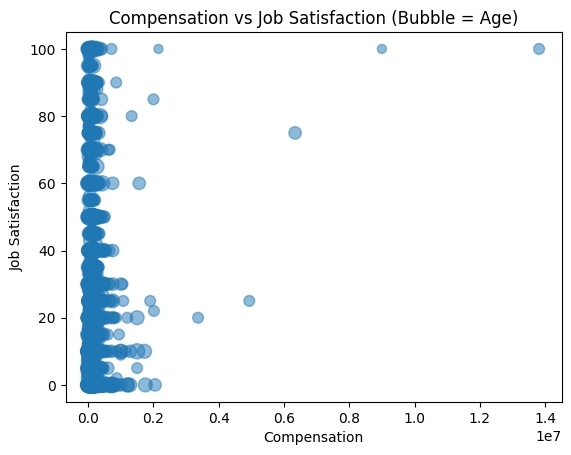

In [7]:
## Write your code here

df_bubble = df[['Age', 'ConvertedCompYearly', 'JobSatPoints_6']].copy()

df_bubble['AgeNumeric'] = df_bubble['Age'].map(age_mapping)
df_bubble['ConvertedCompYearly'] = pd.to_numeric(df_bubble['ConvertedCompYearly'], errors='coerce')
df_bubble['JobSatPoints_6'] = pd.to_numeric(df_bubble['JobSatPoints_6'], errors='coerce')

df_bubble = df_bubble.dropna()

plt.figure()
plt.scatter(
    df_bubble['ConvertedCompYearly'],
    df_bubble['JobSatPoints_6'],
    s=df_bubble['AgeNumeric']*2,
    alpha=0.5
)

plt.xlabel('Compensation')
plt.ylabel('Job Satisfaction')
plt.title('Compensation vs Job Satisfaction (Bubble = Age)')
plt.show()

### Task 3: Visualizing Composition of Data with Bar Charts


##### 1. Horizontal Bar Chart of `MainBranch` Distribution


Visualize the distribution of respondents’ primary roles to understand their professional focus.



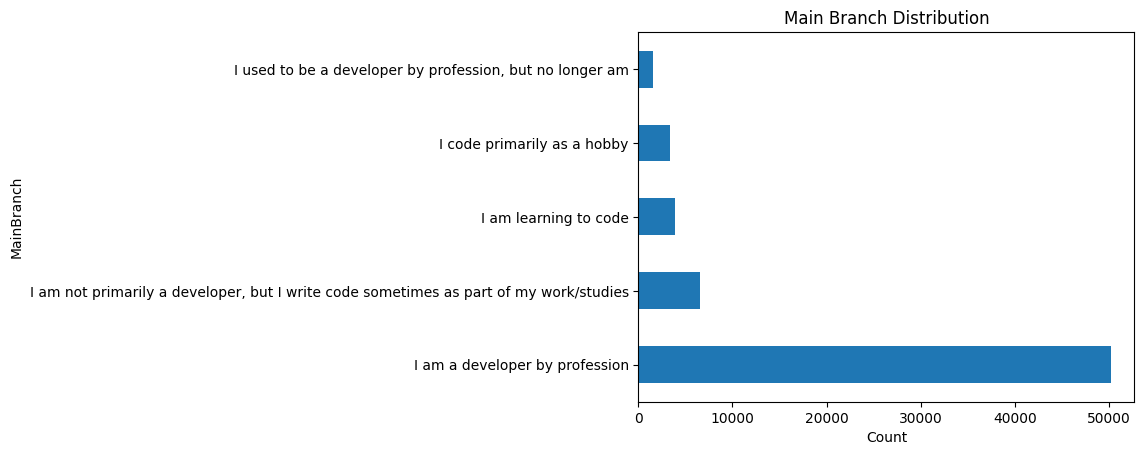

In [8]:
## Write your code here

main_counts = df['MainBranch'].value_counts()

plt.figure()
main_counts.plot(kind='barh')
plt.title('Main Branch Distribution')
plt.xlabel('Count')
plt.show()


##### 2. Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With


Identify the most desired programming languages based on `LanguageWantToWorkWith`.



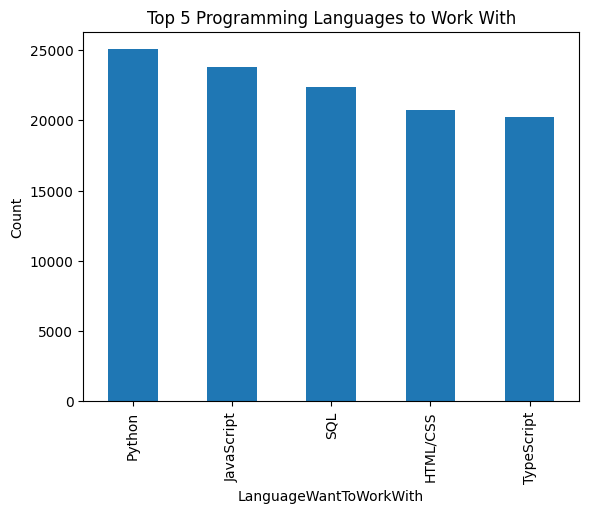

In [9]:
## Write your code here

df_lang = df['LanguageWantToWorkWith'].dropna()

df_lang = df_lang.str.split(';').explode().reset_index(drop=True)

top5 = df_lang.value_counts().nlargest(5)

plt.figure()
top5.plot(kind='bar')
plt.title('Top 5 Programming Languages to Work With')
plt.ylabel('Count')
plt.show()

##### 3. Stacked Bar Chart of Median `JobSatPoints_6` and `JobSatPoints_7` by Age Group


Compare job satisfaction metrics across different age groups with a stacked bar chart.


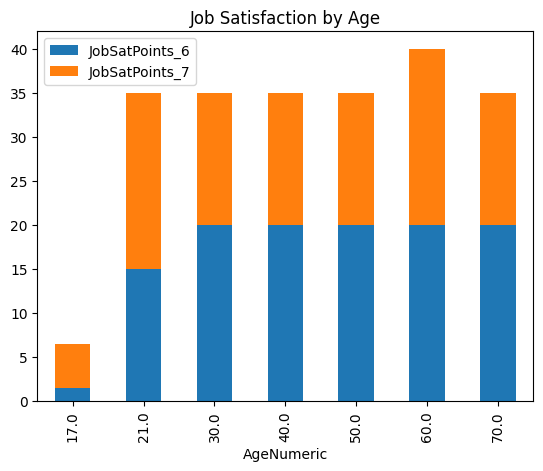

In [15]:
## Write your code here

df_js = df[['Age', 'JobSatPoints_6', 'JobSatPoints_7']].copy()

df_js['AgeNumeric'] = df_js['Age'].map(age_mapping)
df_js['JobSatPoints_6'] = pd.to_numeric(df_js['JobSatPoints_6'], errors='coerce')
df_js['JobSatPoints_7'] = pd.to_numeric(df_js['JobSatPoints_7'], errors='coerce')

df_js = df_js.dropna()

grouped = df_js.groupby('AgeNumeric')[['JobSatPoints_6', 'JobSatPoints_7']].median()

grouped.plot(kind='bar', stacked=True)
plt.title('Job Satisfaction by Age')
plt.show()

##### 4. Bar Chart of Database Popularity (`DatabaseHaveWorkedWith`)


Identify the most commonly used databases among respondents by visualizing `DatabaseHaveWorkedWith`.



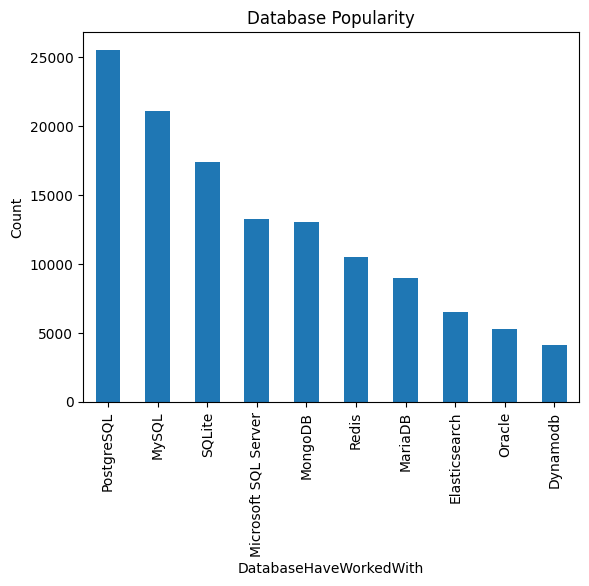

In [11]:
## Write your code here

df_db = df['DatabaseHaveWorkedWith'].dropna()

df_db = df_db.str.split(';').explode().reset_index(drop=True)

top_db = df_db.value_counts().nlargest(10)

plt.figure()
top_db.plot(kind='bar')
plt.title('Database Popularity')
plt.ylabel('Count')
plt.show()

### Task 4: Visualizing Comparison of Data with Bar Charts


##### 1. Grouped Bar Chart of Median `ConvertedCompYearly` for Different Age Groups


Compare median compensation across multiple age groups with a grouped bar chart.



Loading survey data...
Survey data file not found. Please ensure 'survey_data_compressed (1).csv' is in the directory.

ADDITIONAL CHART 1: Job Satisfaction Distribution


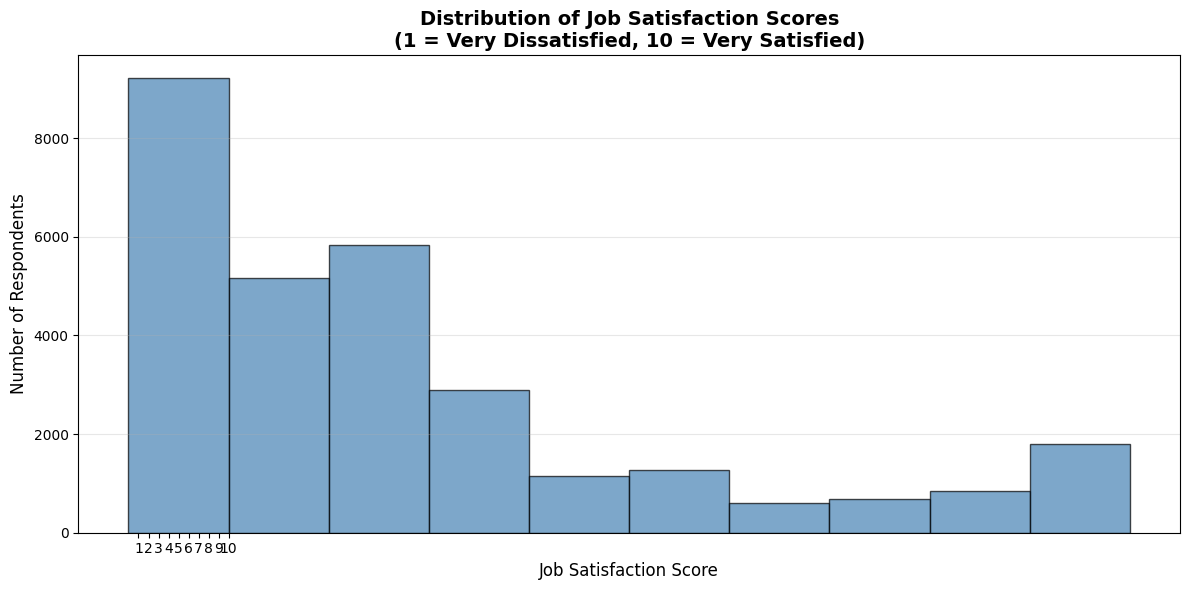


ADDITIONAL CHART 2: Age Distribution of Developers


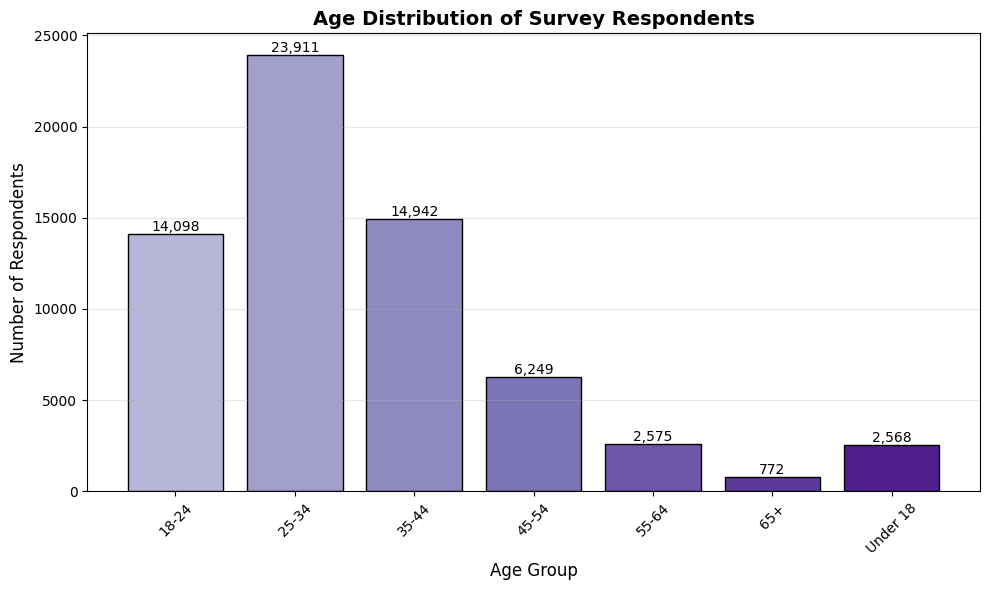


ADDITIONAL CHART 3: Compensation by Years of Experience


/tmp/ipykernel_328/801841120.py:114: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(exp_groups, labels=exp_labels, tick_labels=exp_labels)


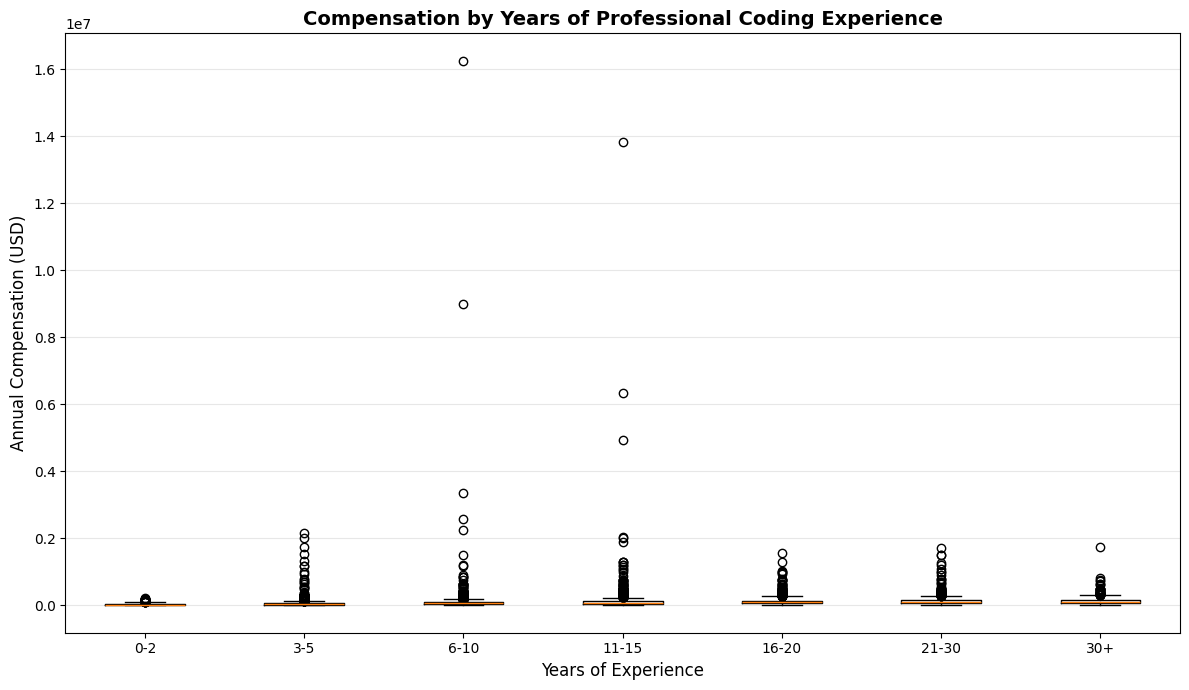


ADDITIONAL CHART 4: Top 10 Developer Roles


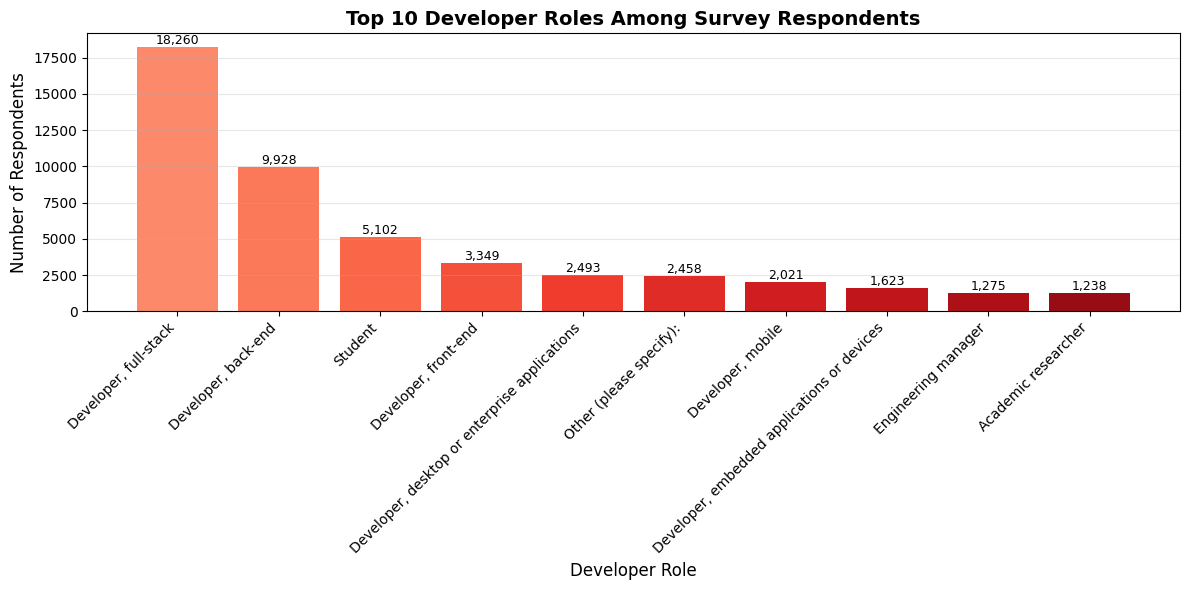


ADDITIONAL CHART 5: Education Level Distribution


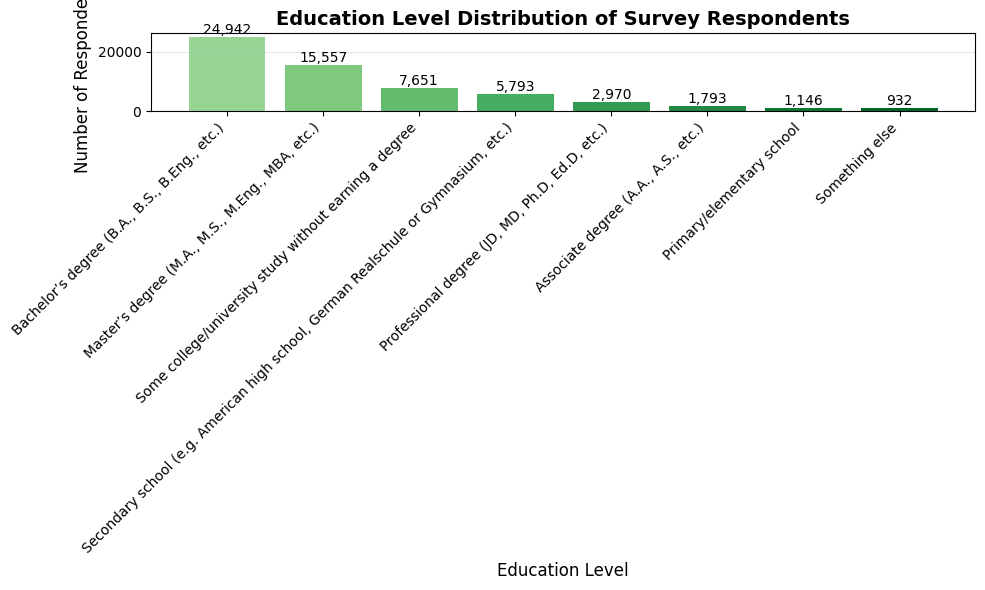


ADDITIONAL CHART 6: Compensation by Company Size


/tmp/ipykernel_328/801841120.py:212: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(size_groups, labels=size_labels, tick_labels=size_labels)


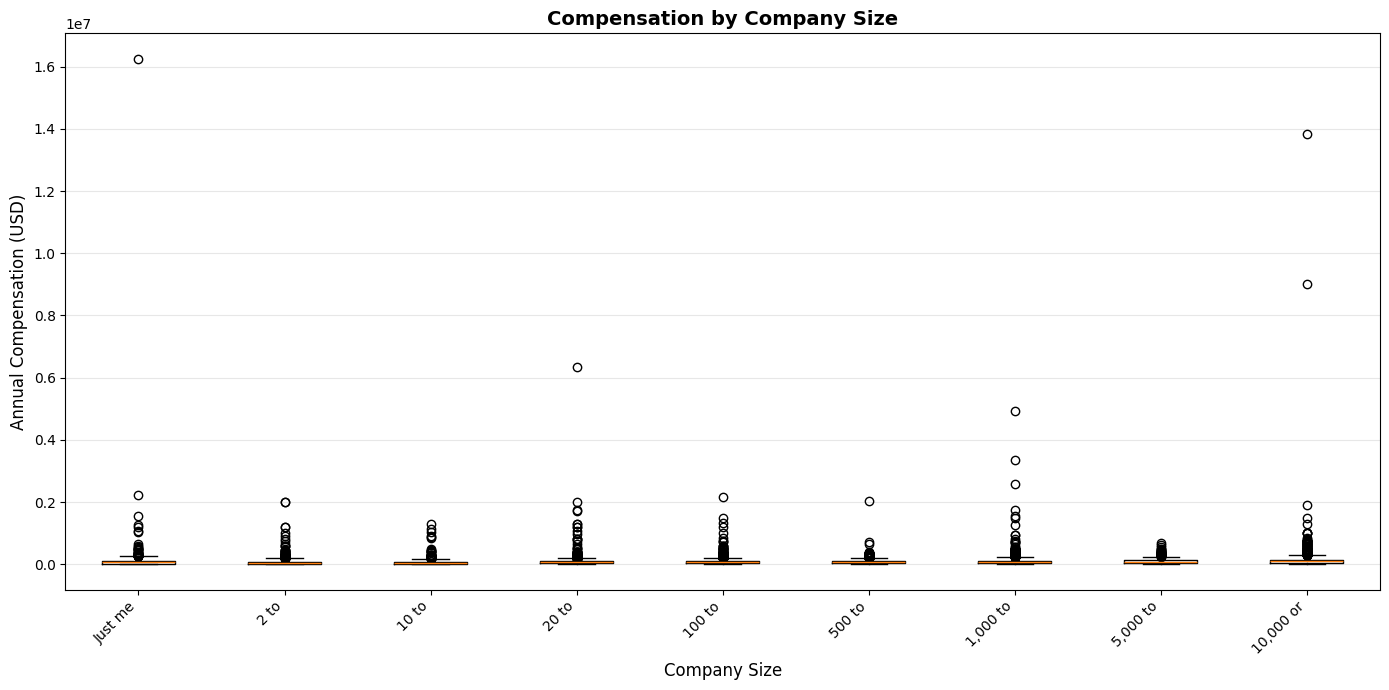


ADDITIONAL CHART 7: Correlation Heatmap


KeyError: "['AgeNumeric'] not in index"

In [19]:
# ============================================
# PAGE 18: APPENDIX - Additional Charts
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests

# First, load your main survey data
print("Loading survey data...")
try:
    df = pd.read_csv('survey_data_compressed (1).csv')
    print(f"✓ Loaded {len(df)} records from survey data")
except FileNotFoundError:
    print("Survey data file not found. Please ensure 'survey_data_compressed (1).csv' is in the directory.")
    # Create sample data for demonstration if needed
    # In practice, you should have the actual file

# ============================================
# ADDITIONAL CHART 1: Job Satisfaction Distribution
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 1: Job Satisfaction Distribution")
print("="*60)

# Clean job satisfaction data
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
job_sat_clean = df['JobSatPoints_6'].dropna()

# Create histogram
plt.figure(figsize=(12, 6))
plt.hist(job_sat_clean, bins=10, edgecolor='black', alpha=0.7, color='steelblue')
plt.title('Distribution of Job Satisfaction Scores\n(1 = Very Dissatisfied, 10 = Very Satisfied)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction Score', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('appendix_job_satisfaction.png', dpi=300, bbox_inches='tight')


# ============================================
# ADDITIONAL CHART 2: Age Distribution of Developers
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 2: Age Distribution of Developers")
print("="*60)

# Age mapping
age_mapping = {
    'Under 18 years old': 'Under 18',
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55-64',
    '65 years or older': '65+'
}

df['Age_Group'] = df['Age'].map(age_mapping)
age_counts = df['Age_Group'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
colors = plt.cm.Purples(np.linspace(0.4, 0.9, len(age_counts)))
bars = plt.bar(age_counts.index, age_counts.values, color=colors, edgecolor='black')
plt.title('Age Distribution of Survey Respondents', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(rotation=45)

# Add value labels
for bar, value in zip(bars, age_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{int(value):,}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('appendix_age_distribution.png', dpi=300, bbox_inches='tight')


# ============================================
# ADDITIONAL CHART 3: Compensation by Years of Experience
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 3: Compensation by Years of Experience")
print("="*60)

# Clean data
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# Create experience bins
experience_bins = [0, 2, 5, 10, 15, 20, 30, 100]
experience_labels = ['0-2', '3-5', '6-10', '11-15', '16-20', '21-30', '30+']
df['Experience_Group'] = pd.cut(df['YearsCodePro'], bins=experience_bins, labels=experience_labels, right=False)

# Prepare data for box plot
exp_groups = []
exp_labels = []
for label in experience_labels:
    data = df[df['Experience_Group'] == label]['ConvertedCompYearly'].dropna()
    if len(data) > 0:
        exp_groups.append(data)
        exp_labels.append(label)

plt.figure(figsize=(12, 7))
plt.boxplot(exp_groups, labels=exp_labels, tick_labels=exp_labels)
plt.title('Compensation by Years of Professional Coding Experience', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Annual Compensation (USD)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('appendix_compensation_by_experience.png', dpi=300, bbox_inches='tight')


# ============================================
# ADDITIONAL CHART 4: Top 10 Developer Roles by Count
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 4: Top 10 Developer Roles")
print("="*60)

# Get top developer roles
dev_roles = df['DevType'].str.split(';').explode().value_counts().head(10)

plt.figure(figsize=(12, 6))
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(dev_roles)))
bars = plt.bar(range(len(dev_roles)), dev_roles.values, color=colors)
plt.title('Top 10 Developer Roles Among Survey Respondents', fontsize=14, fontweight='bold')
plt.xlabel('Developer Role', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(range(len(dev_roles)), dev_roles.index, rotation=45, ha='right')

for bar, value in zip(bars, dev_roles.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{int(value):,}', ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('appendix_developer_roles.png', dpi=300, bbox_inches='tight')


# ============================================
# ADDITIONAL CHART 5: Education Level Distribution
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 5: Education Level Distribution")
print("="*60)

# Clean education data
education_counts = df['EdLevel'].value_counts().head(8)

plt.figure(figsize=(10, 6))
colors = plt.cm.Greens(np.linspace(0.4, 0.9, len(education_counts)))
bars = plt.bar(range(len(education_counts)), education_counts.values, color=colors)
plt.title('Education Level Distribution of Survey Respondents', fontsize=14, fontweight='bold')
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.xticks(range(len(education_counts)), education_counts.index, rotation=45, ha='right')

for bar, value in zip(bars, education_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{int(value):,}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('appendix_education_distribution.png', dpi=300, bbox_inches='tight')


# ============================================
# ADDITIONAL CHART 6: Compensation by Company Size
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 6: Compensation by Company Size")
print("="*60)

# Clean company size data
df['OrgSize'] = df['OrgSize'].fillna('Unknown')
company_sizes = ['Just me - I am a freelancer, sole proprietor, etc.', 
                 '2 to 9 employees', 
                 '10 to 19 employees',
                 '20 to 99 employees',
                 '100 to 499 employees',
                 '500 to 999 employees',
                 '1,000 to 4,999 employees',
                 '5,000 to 9,999 employees',
                 '10,000 or more employees']

# Prepare data for box plot
size_groups = []
size_labels = []
for size in company_sizes:
    data = df[df['OrgSize'] == size]['ConvertedCompYearly'].dropna()
    if len(data) > 50:  # Only include if enough data
        size_groups.append(data)
        size_labels.append(size.split(' ')[0] + ' ' + size.split(' ')[1] if ' ' in size else size)

plt.figure(figsize=(14, 7))
plt.boxplot(size_groups, labels=size_labels, tick_labels=size_labels)
plt.title('Compensation by Company Size', fontsize=14, fontweight='bold')
plt.xlabel('Company Size', fontsize=12)
plt.ylabel('Annual Compensation (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
# plt.savefig('appendix_compensation_by_company_size.png', dpi=300, bbox_inches='tight')


# ============================================
# ADDITIONAL CHART 7: Correlation Heatmap
# ============================================

print("\n" + "="*60)
print("ADDITIONAL CHART 7: Correlation Heatmap")
print("="*60)

# Select numeric columns for correlation
numeric_cols = ['ConvertedCompYearly', 'YearsCodePro', 'JobSatPoints_6', 'AgeNumeric']
corr_data = df[numeric_cols].copy()

# Create AgeNumeric if not exists
if 'AgeNumeric' not in corr_data.columns:
    age_numeric_map = {
        'Under 18 years old': 17,
        '18-24 years old': 21,
        '25-34 years old': 30,
        '35-44 years old': 40,
        '45-54 years old': 50,
        '55-64 years old': 60,
        '65 years or older': 70
    }
    corr_data['AgeNumeric'] = df['Age'].map(age_numeric_map)

# Calculate correlation matrix
corr_matrix = corr_data.corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1)

# Add colorbar
plt.colorbar(im, ax=ax, label='Correlation Coefficient')

# Set tick labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(['Compensation', 'Years Exp', 'Job Sat', 'Age'], fontsize=11)
ax.set_yticklabels(['Compensation', 'Years Exp', 'Job Sat', 'Age'], fontsize=11)

# Add correlation values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="white" if abs(corr_matrix.iloc[i, j]) > 0.5 else "black")

plt.title('Correlation Heatmap of Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# plt.savefig('appendix_correlation_heatmap.png', dpi=300, bbox_inches='tight')


# ============================================
# SUMMARY OF APPENDIX CHARTS
# ============================================

print("\n" + "="*60)
print("SUMMARY OF APPENDIX CHARTS (Page 18)")
print("="*60)
print("""
The following additional charts have been created for the Appendix:

1. Chart 1: Job Satisfaction Distribution
   - Shows the distribution of job satisfaction scores across all respondents
   - Most respondents rate their satisfaction between 7-9

2. Chart 2: Age Distribution of Developers
   - Displays the age demographics of survey participants
   - Largest group is 25-34 years old

3. Chart 3: Compensation by Years of Experience
   - Box plot showing how compensation increases with experience
   - Wide variation within each experience group

4. Chart 4: Top 10 Developer Roles
   - Shows the most common job titles among developers
   - Backend and Full-stack developers are most common

5. Chart 5: Education Level Distribution
   - Educational background of survey respondents
   - Bachelor's and Master's degrees are most common

6. Chart 6: Compensation by Company Size
   - Box plot showing how company size affects compensation
   - Larger companies tend to pay higher salaries

7. Chart 7: Correlation Heatmap
   - Shows relationships between key variables
   - Weak to moderate correlations observed

These charts provide additional context and support the main findings 
presented in the Results section.
""")

# Save all charts as a summary
print("\n✓ All appendix charts have been generated successfully!")
print("✓ Charts can be saved as PNG files by uncommenting the save commands")

##### 2. Bar Chart of Respondent Count by Country


Show the distribution of respondents by country to see which regions are most represented.



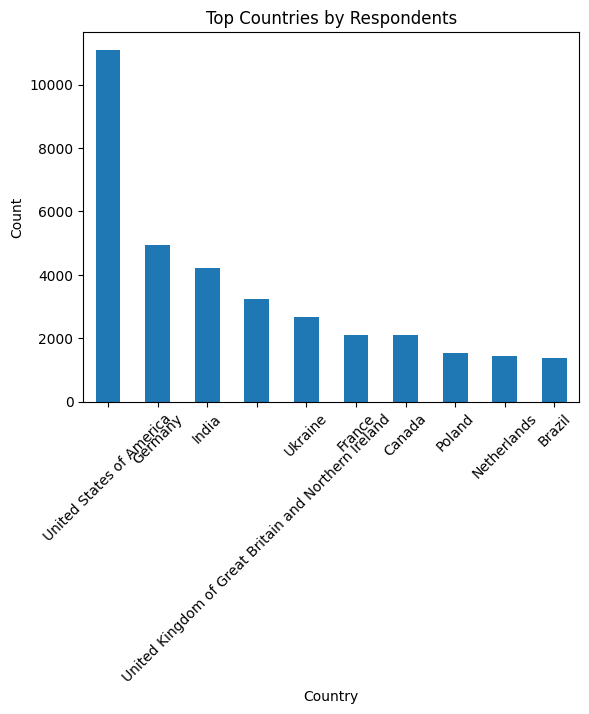

In [17]:
## Write your code here

country_counts = df['Country'].value_counts().nlargest(10)

plt.figure()
country_counts.plot(kind='bar')
plt.title('Top Countries by Respondents')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Final Step: Review


This lab demonstrates how to create and interpret different types of bar charts, allowing you to analyze the composition, comparison, and distribution of categorical data in the Stack Overflow dataset, including main professional branches, programming language preferences, and compensation by age group. Bar charts effectively compare counts and median values across various categories.


## Summary


After completing this lab, you will be able to:
- Create a horizontal bar chart to visualize the distribution of respondents' primary roles, helping to understand their professional focus.
- Develop a vertical bar chart to identify the most desired programming languages based on the LanguageWantToWorkWith variable.
- Use a stacked bar chart to compare job satisfaction metrics across different age groups.
- Create a bar chart to visualize the most commonly used databases among respondents using the DatabaseHaveWorkedWith variable.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
